In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("../../datasets/StudentsPerformance.csv")


In [2]:
df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [4]:
df.isnull().sum()


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
categorical_cols = ["gender", "race/ethnicity", "parental level of education", "lunch", "test preparation course"]
df[categorical_cols] = df[categorical_cols].astype("category")
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   gender                       1000 non-null   category
 1   race/ethnicity               1000 non-null   category
 2   parental level of education  1000 non-null   category
 3   lunch                        1000 non-null   category
 4   test preparation course      1000 non-null   category
 5   math score                   1000 non-null   int64   
 6   reading score                1000 non-null   int64   
 7   writing score                1000 non-null   int64   
dtypes: category(5), int64(3)
memory usage: 28.7 KB


In [6]:
df.columns = df.columns.str.strip()
print("Cleaned Column Names:", list(df.columns))


Cleaned Column Names: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


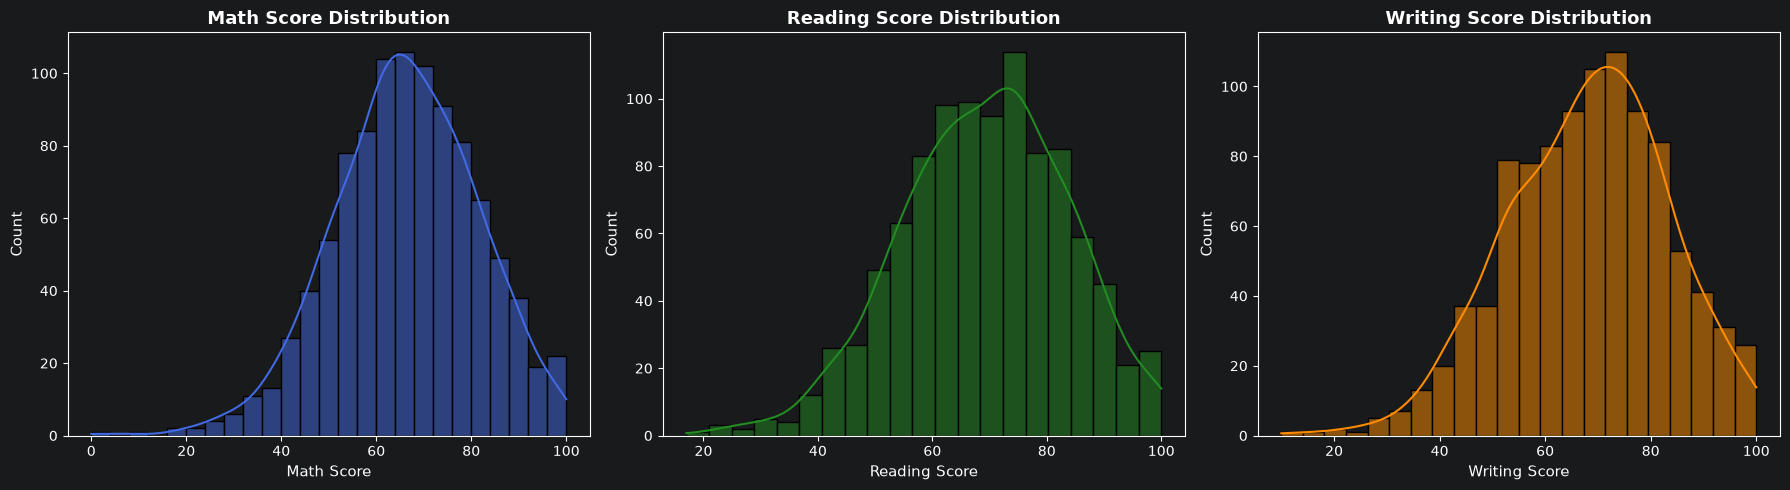

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df["math score"], kde=True, ax=axes[0], color="royalblue")
axes[0].set_title("Math Score Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Math Score", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)

sns.histplot(df["reading score"], kde=True, ax=axes[1], color="forestgreen")
axes[1].set_title("Reading Score Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Reading Score", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)

sns.histplot(df["writing score"], kde=True, ax=axes[2], color="darkorange")
axes[2].set_title("Writing Score Distribution", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Writing Score", fontsize=11)
axes[2].set_ylabel("Count", fontsize=11)

plt.tight_layout()
plt.show()


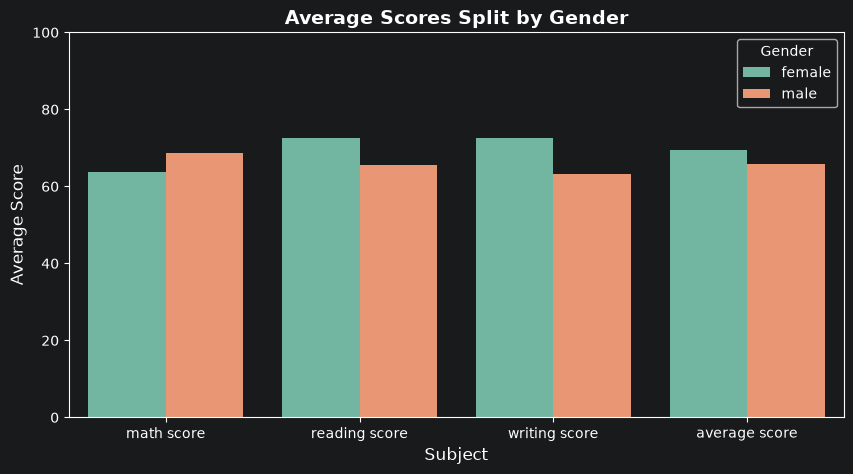

In [8]:
df["average score"] = df[["math score", "reading score", "writing score"]].mean(axis=1)

gender_avg = df.groupby("gender", observed=False)[["math score", "reading score", "writing score", "average score"]].mean().reset_index()
gender_melted = pd.melt(gender_avg, id_vars="gender", var_name="Subject", value_name="Score")

plt.figure(figsize=(10, 5))
sns.barplot(x="Subject", y="Score", hue="gender", data=gender_melted, palette="Set2")
plt.title("Average Scores Split by Gender", fontsize=14, fontweight="bold")
plt.xlabel("Subject", fontsize=12)
plt.ylabel("Average Score", fontsize=12)
plt.ylim(0, 100)
plt.legend(title="Gender")
plt.show()


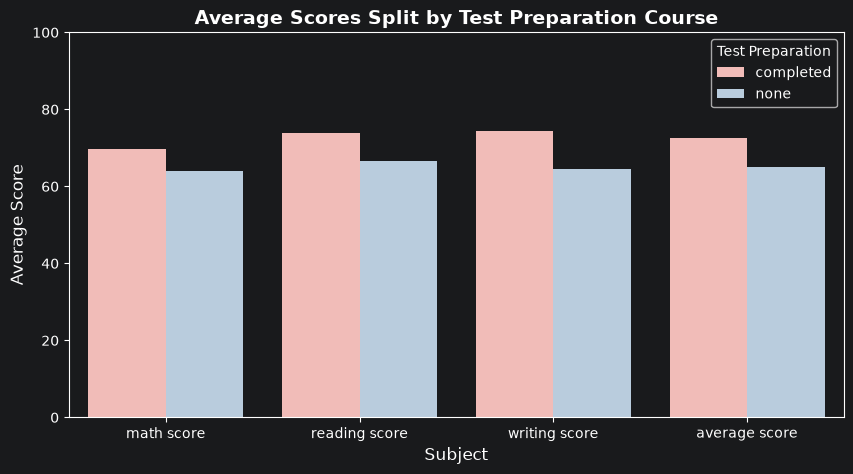

In [9]:
prep_avg = df.groupby("test preparation course", observed=False)[["math score", "reading score", "writing score", "average score"]].mean().reset_index()
prep_melted = pd.melt(prep_avg, id_vars="test preparation course", var_name="Subject", value_name="Score")

plt.figure(figsize=(10, 5))
sns.barplot(x="Subject", y="Score", hue="test preparation course", data=prep_melted, palette="Pastel1")
plt.title("Average Scores Split by Test Preparation Course", fontsize=14, fontweight="bold")
plt.xlabel("Subject", fontsize=12)
plt.ylabel("Average Score", fontsize=12)
plt.ylim(0, 100)
plt.legend(title="Test Preparation")
plt.show()
